<a href="https://colab.research.google.com/github/Fatou-Kine3/github_task/blob/main/SimpleConv1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
## Problem 1

In [10]:
import numpy as np


class SimpleConv1d:
    def __init__(self, w, b):
        self.w = w
        self.b = b

        self.x = None
        self.a = None

    def forward(self, x):
        self.x = x

        N = len(x)
        F = len(self.w)

        N_out = N - F + 1

        self.a = np.zeros(N_out)

        for i in range(N_out):
            for s in range(F):
                self.a[i] += x[i + s] * self.w[s]

            self.a[i] += self.b[0]

        return self.a

    def backward(self, delta_a):
        N = len(self.x)
        F = len(self.w)
        N_out = len(delta_a)

        delta_w = np.zeros_like(self.w, dtype=float)
        delta_b = np.zeros_like(self.b, dtype=float)
        delta_x = np.zeros_like(self.x, dtype=float)

        for i in range(N_out):
            for s in range(F):
                delta_w[s] += delta_a[i] * self.x[i + s]

            delta_b[0] += delta_a[i]

        for j in range(N):
            for s in range(F):
                i = j - s

                if 0 <= i < N_out:
                    delta_x[j] += delta_a[i] * self.w[s]

        return delta_x, delta_w, delta_b

In [ ]:
## Problem 2

In [11]:
def calculate_output_length(Nin, P, F, S):
    if S <= 0:
        raise ValueError("Stride must be positive.")

    padded_length = Nin + 2 * P

    if F > padded_length:
        raise ValueError("Filter size cannot be larger than padded input.")

    return (padded_length - F) // S + 1

In [12]:
print(calculate_output_length(10, 0, 3, 1))
print(calculate_output_length(10, 1, 3, 1))
print(calculate_output_length(10, 0, 3, 2))

8
10
4


In [ ]:
## Problem 3

In [13]:
x = np.array([1, 2, 3, 4])

w = np.array([3, 5, 7])

b = np.array([1])

conv = SimpleConv1d(w, b)

a = conv.forward(x)

print("Forward:")
print(a)

Forward:
[35. 50.]


In [14]:
delta_a = np.array([10, 20])

delta_x, delta_w, delta_b = conv.backward(delta_a)

print("delta_w:")
print(delta_w)

print("delta_b:")
print(delta_b)

print("delta_x:")
print(delta_x)

delta_w:
[ 50.  80. 110.]
delta_b:
[30.]
delta_x:
[ 30. 110. 170. 140.]


In [15]:
np.testing.assert_allclose(
    a,
    np.array([35, 50])
)

np.testing.assert_allclose(
    delta_w,
    np.array([50, 80, 110])
)

np.testing.assert_allclose(
    delta_b,
    np.array([30])
)

np.testing.assert_allclose(
    delta_x,
    np.array([30, 110, 170, 140])
)

print("Problem 3 passed!")

Problem 3 passed!


In [ ]:
## Problem 4

In [16]:
class Conv1d:
    def __init__(self, in_channels, out_channels, filter_size,
                 padding=0, stride=1):

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.filter_size = filter_size
        self.padding = padding
        self.stride = stride

        self.w = np.random.randn(
            out_channels,
            in_channels,
            filter_size
        )

        self.b = np.zeros(out_channels)

        self.x = None
        self.x_padded = None

    def forward(self, x):
        # Problem 4 accepts (channels, length)
        if x.ndim != 2:
            raise ValueError(
                "Problem 4 expects x with shape (channels, length)"
            )

        self.x = x

        in_channels, input_length = x.shape

        if in_channels != self.in_channels:
            raise ValueError("Number of input channels is incorrect.")

        # Padding
        self.x_padded = np.pad(
            x,
            ((0, 0), (self.padding, self.padding)),
            mode="constant"
        )

        padded_length = self.x_padded.shape[1]

        output_length = (
            padded_length - self.filter_size
        ) // self.stride + 1

        output = np.zeros(
            (self.out_channels, output_length)
        )

        for out_c in range(self.out_channels):

            for i in range(output_length):

                start = i * self.stride

                for in_c in range(self.in_channels):

                    for s in range(self.filter_size):

                        output[out_c, i] += (
                            self.x_padded[in_c, start + s]
                            * self.w[out_c, in_c, s]
                        )

                output[out_c, i] += self.b[out_c]

        return output

In [17]:
x = np.array([
    [1, 2, 3, 4],
    [2, 3, 4, 5]
])

w = np.ones((3, 2, 3))

b = np.array([1, 2, 3])

In [18]:
conv = Conv1d(
    in_channels=2,
    out_channels=3,
    filter_size=3
)

conv.w = w.copy()
conv.b = b.copy()

output = conv.forward(x)

print(output)

[[16. 22.]
 [17. 23.]
 [18. 24.]]


In [19]:
expected = np.array([
    [16, 22],
    [17, 23],
    [18, 24]
])

np.testing.assert_allclose(output, expected)

print("Problem 4 passed!")

Problem 4 passed!


In [ ]:
## Problem 5

In [20]:
class Conv1d:
    def __init__(self, in_channels, out_channels, filter_size,
                 padding=0, stride=1):

        if stride <= 0:
            raise ValueError("Stride must be positive.")

        if padding < 0:
            raise ValueError("Padding cannot be negative.")

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.filter_size = filter_size
        self.padding = padding
        self.stride = stride

        self.w = np.random.randn(
            out_channels,
            in_channels,
            filter_size
        )

        self.b = np.zeros(out_channels)

        self.x = None
        self.x_padded = None

    def forward(self, x):

        # Accept either:
        # (channels, length)
        # or
        # (batch, channels, length)

        if x.ndim == 2:
            x = x[np.newaxis, :, :]
            self.single_sample = True
        elif x.ndim == 3:
            self.single_sample = False
        else:
            raise ValueError(
                "x must have shape (channels, length) "
                "or (batch, channels, length)"
            )

        self.x = x

        batch_size, in_channels, input_length = x.shape

        if in_channels != self.in_channels:
            raise ValueError(
                f"Expected {self.in_channels} channels, "
                f"got {in_channels}"
            )

        # Pad ONLY the length axis
        self.x_padded = np.pad(
            x,
            (
                (0, 0),
                (0, 0),
                (self.padding, self.padding)
            ),
            mode="constant"
        )

        padded_length = self.x_padded.shape[2]

        output_length = (
            padded_length - self.filter_size
        ) // self.stride + 1

        output = np.zeros(
            (
                batch_size,
                self.out_channels,
                output_length
            )
        )

        for b in range(batch_size):

            for out_c in range(self.out_channels):

                for i in range(output_length):

                    start = i * self.stride

                    for in_c in range(self.in_channels):

                        for s in range(self.filter_size):

                            output[b, out_c, i] += (
                                self.x_padded[
                                    b, in_c, start + s
                                ]
                                * self.w[
                                    out_c, in_c, s
                                ]
                            )

                    output[b, out_c, i] += self.b[out_c]

        if self.single_sample:
            return output[0]

        return output

In [ ]:
## Problem 6

In [21]:
    def backward(self, d_out):

        if d_out.ndim == 2:
            d_out = d_out[np.newaxis, :, :]

        batch_size = self.x.shape[0]

        output_length = d_out.shape[2]

        dW = np.zeros_like(self.w, dtype=float)
        db = np.zeros_like(self.b, dtype=float)
        dX_padded = np.zeros_like(
            self.x_padded,
            dtype=float
        )

        for b in range(batch_size):

            for out_c in range(self.out_channels):

                for i in range(output_length):

                    start = i * self.stride

                    # Bias gradient
                    db[out_c] += d_out[b, out_c, i]

                    for in_c in range(self.in_channels):

                        for s in range(self.filter_size):

                            # Weight gradient
                            dW[out_c, in_c, s] += (
                                d_out[b, out_c, i]
                                * self.x_padded[
                                    b, in_c, start + s
                                ]
                            )

                            # Input gradient
                            dX_padded[
                                b, in_c, start + s
                            ] += (
                                d_out[b, out_c, i]
                                * self.w[
                                    out_c, in_c, s
                                ]
                            )

        # Remove padding
        if self.padding > 0:
            dX = dX_padded[
                :,
                :,
                self.padding:-self.padding
            ]
        else:
            dX = dX_padded

        if self.single_sample:
            dX = dX[0]

        return dX, dW, db

In [22]:
x_batch = np.array([
    [
        [1, 2, 3, 4],
        [2, 3, 4, 5]
    ],
    [
        [2, 3, 4, 5],
        [3, 4, 5, 6]
    ]
])

conv = Conv1d(
    in_channels=2,
    out_channels=3,
    filter_size=3
)

conv.w = np.ones((3, 2, 3))
conv.b = np.array([1., 2., 3.])

output = conv.forward(x_batch)

print("Input shape:", x_batch.shape)
print("Output shape:", output.shape)

Input shape: (2, 2, 4)
Output shape: (2, 3, 2)


In [24]:
import numpy as np


class Conv1d:

    def __init__(
        self,
        in_channels,
        out_channels,
        filter_size,
        padding=0,
        stride=1
    ):

        if stride <= 0:
            raise ValueError("Stride must be positive.")

        if padding < 0:
            raise ValueError("Padding cannot be negative.")

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.filter_size = filter_size
        self.padding = padding
        self.stride = stride

        # Weight shape:
        # (out_channels, in_channels, filter_size)
        self.w = np.random.randn(
            out_channels,
            in_channels,
            filter_size
        )

        # Bias shape:
        # (out_channels,)
        self.b = np.zeros(out_channels)

        # Variables saved during forward propagation
        self.x = None
        self.x_padded = None
        self.single_sample = False


    def forward(self, x):

        # -----------------------------------
        # Accept:
        # (channels, length)
        # OR
        # (batch, channels, length)
        # -----------------------------------

        if x.ndim == 2:

            # Convert:
            # (channels, length)
            #
            # into:
            # (1, channels, length)

            x = x[np.newaxis, :, :]

            self.single_sample = True

        elif x.ndim == 3:

            self.single_sample = False

        else:

            raise ValueError(
                "x must have shape "
                "(channels, length) or "
                "(batch, channels, length)"
            )


        # Save original input
        self.x = x

        batch_size, in_channels, input_length = x.shape


        # Check channels
        if in_channels != self.in_channels:

            raise ValueError(
                f"Expected {self.in_channels} input channels, "
                f"but got {in_channels}."
            )


        # -----------------------------------
        # Padding
        # Pad ONLY the length dimension
        # -----------------------------------

        self.x_padded = np.pad(
            x,
            (
                (0, 0),                       # batch
                (0, 0),                       # channels
                (self.padding, self.padding)  # length
            ),
            mode="constant"
        )


        padded_length = self.x_padded.shape[2]


        # -----------------------------------
        # Calculate output length
        # -----------------------------------

        output_length = (
            padded_length - self.filter_size
        ) // self.stride + 1


        # -----------------------------------
        # Create output
        # -----------------------------------

        output = np.zeros(
            (
                batch_size,
                self.out_channels,
                output_length
            )
        )


        # -----------------------------------
        # Forward convolution
        # -----------------------------------

        for b in range(batch_size):

            for out_c in range(self.out_channels):

                for i in range(output_length):

                    start = i * self.stride

                    for in_c in range(self.in_channels):

                        for s in range(self.filter_size):

                            output[b, out_c, i] += (
                                self.x_padded[
                                    b,
                                    in_c,
                                    start + s
                                ]
                                *
                                self.w[
                                    out_c,
                                    in_c,
                                    s
                                ]
                            )

                    # Add bias
                    output[b, out_c, i] += self.b[out_c]


        # If original input was 2D,
        # return 2D output
        if self.single_sample:

            return output[0]

        return output


    def backward(self, d_out):

        # -----------------------------------
        # Make sure d_out is 3D
        # -----------------------------------

        if d_out.ndim == 2:

            d_out = d_out[np.newaxis, :, :]


        # -----------------------------------
        # Get dimensions
        # -----------------------------------

        batch_size = self.x.shape[0]

        output_length = d_out.shape[2]


        # -----------------------------------
        # Initialize gradients
        # -----------------------------------

        dW = np.zeros_like(
            self.w,
            dtype=float
        )

        db = np.zeros_like(
            self.b,
            dtype=float
        )

        dX_padded = np.zeros_like(
            self.x_padded,
            dtype=float
        )


        # -----------------------------------
        # Backpropagation
        # -----------------------------------

        for b in range(batch_size):

            for out_c in range(self.out_channels):

                for i in range(output_length):

                    start = i * self.stride

                    # -------------------------
                    # Bias gradient
                    # -------------------------

                    db[out_c] += d_out[
                        b,
                        out_c,
                        i
                    ]


                    # -------------------------
                    # Weight + input gradients
                    # -------------------------

                    for in_c in range(self.in_channels):

                        for s in range(self.filter_size):

                            # Weight gradient
                            dW[
                                out_c,
                                in_c,
                                s
                            ] += (
                                d_out[
                                    b,
                                    out_c,
                                    i
                                ]
                                *
                                self.x_padded[
                                    b,
                                    in_c,
                                    start + s
                                ]
                            )


                            # Input gradient
                            dX_padded[
                                b,
                                in_c,
                                start + s
                            ] += (
                                d_out[
                                    b,
                                    out_c,
                                    i
                                ]
                                *
                                self.w[
                                    out_c,
                                    in_c,
                                    s
                                ]
                            )


        # -----------------------------------
        # Remove padding from dX
        # -----------------------------------

        if self.padding > 0:

            dX = dX_padded[
                :,
                :,
                self.padding:-self.padding
            ]

        else:

            dX = dX_padded


        # -----------------------------------
        # Return same dimensionality
        # as original input
        # -----------------------------------

        if self.single_sample:

            dX = dX[0]


        return dX, dW, db

In [25]:
conv = Conv1d(
    in_channels=2,
    out_channels=3,
    filter_size=3
)

conv.w = np.ones((3, 2, 3))
conv.b = np.array([1., 2., 3.])

In [26]:
x_batch = np.array([
    [
        [1, 2, 3, 4],
        [2, 3, 4, 5]
    ],
    [
        [2, 3, 4, 5],
        [3, 4, 5, 6]
    ]
])

In [27]:
output = conv.forward(x_batch)

print("Input shape:", x_batch.shape)
print("Output shape:", output.shape)

Input shape: (2, 2, 4)
Output shape: (2, 3, 2)


In [28]:
d_out = np.ones_like(output)

dX, dW, db = conv.backward(d_out)

print("dX shape:", dX.shape)
print("dW shape:", dW.shape)
print("db shape:", db.shape)

dX shape: (2, 2, 4)
dW shape: (3, 2, 3)
db shape: (3,)


In [ ]:
## Problem 7

In [29]:
x = np.array([
    [1, 2, 3, 4, 5, 6]
])

conv = Conv1d(
    in_channels=1,
    out_channels=1,
    filter_size=3,
    padding=0,
    stride=2
)

conv.w = np.array([
    [[1, 1, 1]]
])

conv.b = np.array([0.])

In [30]:
output = conv.forward(x)

print("Output:")
print(output)

print("Output shape:")
print(output.shape)

Output:
[[ 6. 12.]]
Output shape:
(1, 2)


In [32]:
d_out = np.ones_like(output)

dX, dW, db = conv.backward(d_out)

print("dX:")
print(dX)

print("dX shape:", dX.shape)
print("dW:", dW)
print("db:", db)

dX:
[[1. 1. 2. 1. 1. 0.]]
dX shape: (1, 6)
dW: [[[4. 6. 8.]]]
db: [2.]


In [33]:
expected_output = np.array([
    [[6., 12.]]
])

expected_dX = np.array([
    [[1., 1., 2., 2., 1., 0.]]
])

In [36]:
import numpy as np


# ============================================================
# PROBLEM 7: Support arbitrary stride
# ============================================================

class Conv1d:

    def __init__(
        self,
        in_channels,
        out_channels,
        filter_size,
        padding=0,
        stride=1
    ):

        if stride <= 0:
            raise ValueError("Stride must be positive.")

        if padding < 0:
            raise ValueError("Padding cannot be negative.")

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.filter_size = filter_size
        self.padding = padding
        self.stride = stride

        # Weight shape:
        # (out_channels, in_channels, filter_size)
        self.w = np.random.randn(
            out_channels,
            in_channels,
            filter_size
        )

        # Bias shape:
        # (out_channels,)
        self.b = np.zeros(out_channels)

        self.x = None
        self.x_padded = None


    # --------------------------------------------------------
    # Forward propagation
    # --------------------------------------------------------

    def forward(self, x):

        # Problem 7 uses:
        # (batch_size, channels, length)

        if x.ndim != 3:
            raise ValueError(
                "Input must have shape "
                "(batch_size, channels, length)."
            )

        self.x = x

        batch_size, in_channels, input_length = x.shape

        if in_channels != self.in_channels:
            raise ValueError(
                f"Expected {self.in_channels} input channels, "
                f"but got {in_channels}."
            )

        # ----------------------------------------------------
        # Padding ONLY on the length axis
        # ----------------------------------------------------

        self.x_padded = np.pad(
            x,
            (
                (0, 0),                       # batch
                (0, 0),                       # channels
                (self.padding, self.padding)  # length
            ),
            mode="constant"
        )

        padded_length = self.x_padded.shape[2]

        # ----------------------------------------------------
        # Output length
        #
        # Nout = floor((Nin + 2P - F) / S) + 1
        # ----------------------------------------------------

        output_length = (
            padded_length - self.filter_size
        ) // self.stride + 1

        # ----------------------------------------------------
        # Output
        # ----------------------------------------------------

        output = np.zeros(
            (
                batch_size,
                self.out_channels,
                output_length
            )
        )

        # ----------------------------------------------------
        # Convolution
        # ----------------------------------------------------

        for b in range(batch_size):

            for out_c in range(self.out_channels):

                for i in range(output_length):

                    # IMPORTANT:
                    # stride determines the starting position
                    start = i * self.stride

                    for in_c in range(self.in_channels):

                        for s in range(self.filter_size):

                            output[b, out_c, i] += (
                                self.x_padded[
                                    b,
                                    in_c,
                                    start + s
                                ]
                                *
                                self.w[
                                    out_c,
                                    in_c,
                                    s
                                ]
                            )

                    # Add bias
                    output[b, out_c, i] += self.b[out_c]

        return output


    # --------------------------------------------------------
    # Backward propagation
    # --------------------------------------------------------

    def backward(self, d_out):

        if d_out.ndim != 3:
            raise ValueError(
                "d_out must have shape "
                "(batch_size, out_channels, output_length)."
            )

        batch_size = self.x.shape[0]

        output_length = d_out.shape[2]

        # ----------------------------------------------------
        # Initialize gradients
        # ----------------------------------------------------

        dW = np.zeros_like(
            self.w,
            dtype=float
        )

        db = np.zeros_like(
            self.b,
            dtype=float
        )

        dX_padded = np.zeros_like(
            self.x_padded,
            dtype=float
        )

        # ----------------------------------------------------
        # Backward propagation
        # ----------------------------------------------------

        for b in range(batch_size):

            for out_c in range(self.out_channels):

                for i in range(output_length):

                    # IMPORTANT:
                    # use the same stride as forward
                    start = i * self.stride

                    # Bias gradient
                    db[out_c] += d_out[
                        b,
                        out_c,
                        i
                    ]

                    for in_c in range(self.in_channels):

                        for s in range(self.filter_size):

                            # Weight gradient
                            dW[
                                out_c,
                                in_c,
                                s
                            ] += (
                                d_out[
                                    b,
                                    out_c,
                                    i
                                ]
                                *
                                self.x_padded[
                                    b,
                                    in_c,
                                    start + s
                                ]
                            )

                            # Input gradient
                            dX_padded[
                                b,
                                in_c,
                                start + s
                            ] += (
                                d_out[
                                    b,
                                    out_c,
                                    i
                                ]
                                *
                                self.w[
                                    out_c,
                                    in_c,
                                    s
                                ]
                            )

        # ----------------------------------------------------
        # Remove padding
        # ----------------------------------------------------

        if self.padding > 0:

            dX = dX_padded[
                :,
                :,
                self.padding:-self.padding
            ]

        else:

            dX = dX_padded

        return dX, dW, db


# ============================================================
# TEST PROBLEM 7
# ============================================================

# Input:
# (batch_size, channels, length)
x = np.array([
    [
        [1, 2, 3, 4, 5, 6]
    ]
])

# Create Conv1d
conv = Conv1d(
    in_channels=1,
    out_channels=1,
    filter_size=3,
    padding=0,
    stride=2
)

# Simple filter
conv.w = np.array([
    [
        [1, 1, 1]
    ]
])

# Bias
conv.b = np.array([0.0])


# ============================================================
# Forward test
# ============================================================

output = conv.forward(x)

print("Input shape:")
print(x.shape)

print("\nOutput:")
print(output)

print("\nOutput shape:")
print(output.shape)


expected_output = np.array([
    [
        [6., 12.]
    ]
])

np.testing.assert_allclose(
    output,
    expected_output
)

print("\n✓ Forward propagation passed!")


# ============================================================
# Backward test
# ============================================================

d_out = np.ones_like(output)

dX, dW, db = conv.backward(d_out)

print("\ndX:")
print(dX)

print("\ndX shape:")
print(dX.shape)

print("\ndW:")
print(dW)

print("\ndW shape:")
print(dW.shape)

print("\ndb:")
print(db)

print("\ndb shape:")
print(db.shape)


expected_dX = np.array([
    [
        [1., 1., 2., 1., 1., 0.]
    ]
])

expected_dW = np.array([
    [
        [4., 6., 8.]
    ]
])

expected_db = np.array([2.])


np.testing.assert_allclose(
    dX,
    expected_dX
)

np.testing.assert_allclose(
    dW,
    expected_dW
)

np.testing.assert_allclose(
    db,
    expected_db
)

print("\n✓ Backward propagation passed!")
print("\n🎉 Problem 7 passed successfully!")

Input shape:
(1, 1, 6)

Output:
[[[ 6. 12.]]]

Output shape:
(1, 1, 2)

✓ Forward propagation passed!

dX:
[[[1. 1. 2. 1. 1. 0.]]]

dX shape:
(1, 1, 6)

dW:
[[[4. 6. 8.]]]

dW shape:
(1, 1, 3)

db:
[2.]

db shape:
(1,)

✓ Backward propagation passed!

🎉 Problem 7 passed successfully!


In [ ]:
## Problem 8

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [38]:
# Normalize pixel values from [0, 255] to [0, 1]
X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

# Flatten each 28x28 image into 784 values
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (60000, 784)
X_test shape: (10000, 784)


In [39]:
X_train = X_train[:, np.newaxis, :]
X_test = X_test[:, np.newaxis, :]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (60000, 1, 784)
X_test shape: (10000, 1, 784)


In [40]:
X_train_small = X_train[:5000]
y_train_small = y_train[:5000]

X_test_small = X_test[:1000]
y_test_small = y_test[:1000]

print("Training:", X_train_small.shape)
print("Testing:", X_test_small.shape)

Training: (5000, 1, 784)
Testing: (1000, 1, 784)


In [41]:
conv = Conv1d(
    in_channels=1,
    out_channels=4,
    filter_size=5,
    padding=2,
    stride=1
)

print("Weights shape:", conv.w.shape)
print("Bias shape:", conv.b.shape)

Weights shape: (4, 1, 5)
Bias shape: (4,)


In [42]:
test_output = conv.forward(X_train_small[:10])

print("Conv output shape:", test_output.shape)

Conv output shape: (10, 4, 784)


In [43]:
def relu(x):
    return np.maximum(0, x)


def relu_backward(dout, x):
    return dout * (x > 0)


# Test the convolution + ReLU
conv_output = conv.forward(X_train_small[:10])
relu_output = relu(conv_output)

print("Conv output shape:", conv_output.shape)
print("ReLU output shape:", relu_output.shape)

Conv output shape: (10, 4, 784)
ReLU output shape: (10, 4, 784)


In [44]:
batch_size = relu_output.shape[0]

flattened = relu_output.reshape(batch_size, -1)

print("Flattened shape:", flattened.shape)

Flattened shape: (10, 3136)


In [45]:
input_size = 4 * 784
output_size = 10

# Initialize weights and bias
W_fc = np.random.randn(input_size, output_size) * 0.01
b_fc = np.zeros(output_size)

print("W_fc shape:", W_fc.shape)
print("b_fc shape:", b_fc.shape)

W_fc shape: (3136, 10)
b_fc shape: (10,)


In [46]:
logits = flattened @ W_fc + b_fc

print("Logits shape:", logits.shape)

Logits shape: (10, 10)


In [47]:
def softmax(x):
    x_shifted = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x_shifted)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)


probs = softmax(logits)

print("Probabilities shape:", probs.shape)
print("First sample probabilities:", probs[0])
print("Sum of probabilities:", np.sum(probs[0]))

Probabilities shape: (10, 10)
First sample probabilities: [0.08825666 0.08219257 0.05366182 0.12427333 0.04188578 0.19266374
 0.17626745 0.07573856 0.08522428 0.0798358 ]
Sum of probabilities: 1.0


In [48]:
def one_hot(y, num_classes=10):
    result = np.zeros((len(y), num_classes))
    result[np.arange(len(y)), y] = 1
    return result


def cross_entropy_loss(probs, y):
    y_one_hot = one_hot(y, probs.shape[1])

    # Avoid log(0)
    probs_clipped = np.clip(probs, 1e-15, 1.0)

    loss = -np.sum(y_one_hot * np.log(probs_clipped)) / len(y)

    return loss


y_batch = y_train_small[:10]

loss = cross_entropy_loss(probs, y_batch)

print("Cross-entropy loss:", loss)

Cross-entropy loss: 2.250287297251174


In [49]:
predictions = np.argmax(probs, axis=1)

accuracy = np.mean(predictions == y_batch)

print("Predictions:", predictions)
print("True labels:", y_batch)
print("Accuracy:", accuracy)

Predictions: [5 7 1 0 7 0 1 0 1 5]
True labels: [5 0 4 1 9 2 1 3 1 4]
Accuracy: 0.3


In [50]:
# Number of samples in the batch
batch_size = len(y_batch)

# --------------------------------------------------
# 1. Gradient of Cross-Entropy + Softmax
# --------------------------------------------------

y_one_hot = one_hot(y_batch, 10)

# dL/dlogits
d_logits = (probs - y_one_hot) / batch_size

print("d_logits shape:", d_logits.shape)


# --------------------------------------------------
# 2. Backprop through Fully Connected layer
# --------------------------------------------------

# Gradient of FC weights
dW_fc = flattened.T @ d_logits

# Gradient of FC bias
db_fc = np.sum(d_logits, axis=0)

# Gradient with respect to flattened input
d_flattened = d_logits @ W_fc.T

print("dW_fc shape:", dW_fc.shape)
print("db_fc shape:", db_fc.shape)
print("d_flattened shape:", d_flattened.shape)


# --------------------------------------------------
# 3. Backprop through Flatten
# --------------------------------------------------

d_relu_output = d_flattened.reshape(relu_output.shape)

print("d_relu_output shape:", d_relu_output.shape)


# --------------------------------------------------
# 4. Backprop through ReLU
# --------------------------------------------------

d_conv_output = relu_backward(d_relu_output, conv_output)

print("d_conv_output shape:", d_conv_output.shape)


# --------------------------------------------------
# 5. Backprop through Conv1d
# --------------------------------------------------

dX, dW_conv, db_conv = conv.backward(d_conv_output)

print("dX shape:", dX.shape)
print("dW_conv shape:", dW_conv.shape)
print("db_conv shape:", db_conv.shape)

d_logits shape: (10, 10)
dW_fc shape: (3136, 10)
db_fc shape: (10,)
d_flattened shape: (10, 3136)
d_relu_output shape: (10, 4, 784)
d_conv_output shape: (10, 4, 784)
dX shape: (10, 1, 784)
dW_conv shape: (4, 1, 5)
db_conv shape: (4,)


In [51]:
learning_rate = 0.01

# Update fully connected layer
W_fc -= learning_rate * dW_fc
b_fc -= learning_rate * db_fc

# Update Conv1d layer
conv.w -= learning_rate * dW_conv
conv.b -= learning_rate * db_conv

print("Weights updated successfully!")

Weights updated successfully!


In [52]:
# --------------------------------------------------
# Training settings
# --------------------------------------------------

epochs = 5
batch_size = 32
learning_rate = 0.01

train_losses = []
val_losses = []

num_samples = len(X_train_small)


# --------------------------------------------------
# Training loop
# --------------------------------------------------

for epoch in range(epochs):

    # Shuffle training data
    indices = np.random.permutation(num_samples)

    X_train_shuffled = X_train_small[indices]
    y_train_shuffled = y_train_small[indices]

    epoch_loss = 0
    num_batches = 0

    for start in range(0, num_samples, batch_size):

        end = min(start + batch_size, num_samples)

        X_batch = X_train_shuffled[start:end]
        y_batch = y_train_shuffled[start:end]

        actual_batch_size = len(y_batch)

        # ==========================================
        # FORWARD PASS
        # ==========================================

        # Conv1d
        conv_output = conv.forward(X_batch)

        # ReLU
        relu_output = relu(conv_output)

        # Flatten
        flattened = relu_output.reshape(actual_batch_size, -1)

        # Fully connected
        logits = flattened @ W_fc + b_fc

        # Softmax
        probs = softmax(logits)

        # Loss
        loss = cross_entropy_loss(probs, y_batch)

        epoch_loss += loss
        num_batches += 1

        # ==========================================
        # BACKWARD PASS
        # ==========================================

        y_one_hot = one_hot(y_batch, 10)

        # Softmax + Cross Entropy
        d_logits = (probs - y_one_hot) / actual_batch_size

        # Fully connected
        dW_fc = flattened.T @ d_logits
        db_fc = np.sum(d_logits, axis=0)

        d_flattened = d_logits @ W_fc.T

        # Flatten backward
        d_relu_output = d_flattened.reshape(relu_output.shape)

        # ReLU backward
        d_conv_output = relu_backward(
            d_relu_output,
            conv_output
        )

        # Conv1d backward
        dX, dW_conv, db_conv = conv.backward(d_conv_output)

        # ==========================================
        # UPDATE PARAMETERS
        # ==========================================

        W_fc -= learning_rate * dW_fc
        b_fc -= learning_rate * db_fc

        conv.w -= learning_rate * dW_conv
        conv.b -= learning_rate * db_conv

    # Average training loss
    average_train_loss = epoch_loss / num_batches
    train_losses.append(average_train_loss)

    print(
        f"Epoch {epoch + 1}/{epochs} "
        f"- Training Loss: {average_train_loss:.4f}"
    )

Epoch 1/5 - Training Loss: 0.6646
Epoch 2/5 - Training Loss: 0.3702
Epoch 3/5 - Training Loss: 0.3250
Epoch 4/5 - Training Loss: 0.2901
Epoch 5/5 - Training Loss: 0.2710


In [53]:
# Forward pass on test data

test_conv_output = conv.forward(X_test_small)

test_relu_output = relu(test_conv_output)

test_flattened = test_relu_output.reshape(
    len(X_test_small), -1
)

test_logits = test_flattened @ W_fc + b_fc

test_probs = softmax(test_logits)

# Test loss
test_loss = cross_entropy_loss(
    test_probs,
    y_test_small
)

# Predictions
test_predictions = np.argmax(test_probs, axis=1)

# Accuracy
test_accuracy = np.mean(
    test_predictions == y_test_small
)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)
print("Test accuracy (%):", test_accuracy * 100)

Test loss: 0.37417402387900767
Test accuracy: 0.895
Test accuracy (%): 89.5


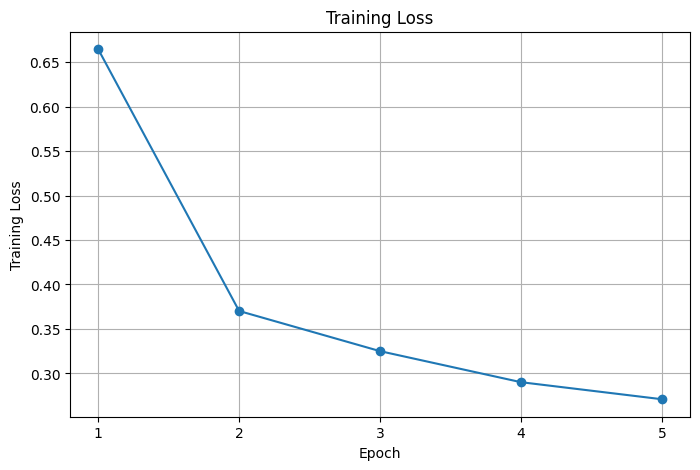

In [54]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    train_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss")

plt.xticks(range(1, epochs + 1))
plt.grid(True)

plt.show()

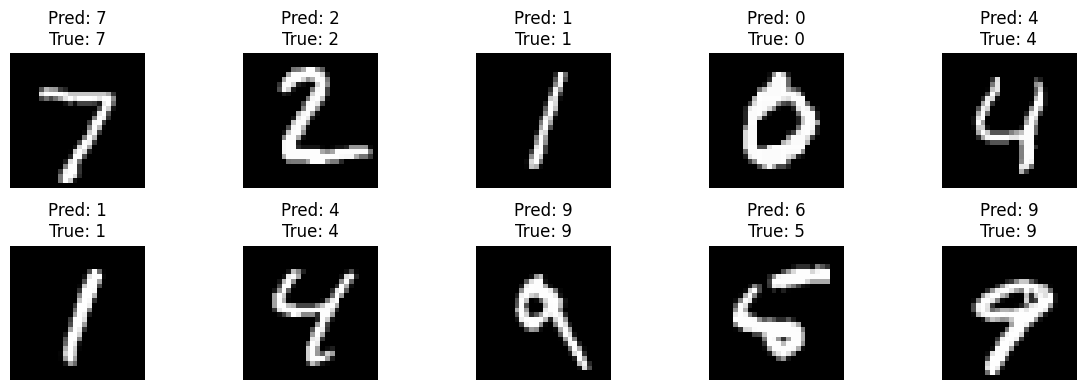

In [55]:
num_images = 10

plt.figure(figsize=(12, 4))

for i in range(num_images):

    plt.subplot(2, 5, i + 1)

    # Original 28x28 image
    image = X_test_small[i].reshape(28, 28)

    plt.imshow(image, cmap="gray")

    plt.title(
        f"Pred: {test_predictions[i]}\n"
        f"True: {y_test_small[i]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [56]:
# --------------------------------------------------
# Training settings
# --------------------------------------------------

epochs = 5
batch_size = 32
learning_rate = 0.01

train_losses = []
val_losses = []

num_samples = len(X_train_small)


# --------------------------------------------------
# Training loop
# --------------------------------------------------

for epoch in range(epochs):

    # Shuffle training data
    indices = np.random.permutation(num_samples)

    X_train_shuffled = X_train_small[indices]
    y_train_shuffled = y_train_small[indices]

    epoch_loss = 0
    num_batches = 0

    # ==============================================
    # TRAINING
    # ==============================================

    for start in range(0, num_samples, batch_size):

        end = min(start + batch_size, num_samples)

        X_batch = X_train_shuffled[start:end]
        y_batch = y_train_shuffled[start:end]

        actual_batch_size = len(y_batch)

        # ---------- Forward ----------

        conv_output = conv.forward(X_batch)

        relu_output = relu(conv_output)

        flattened = relu_output.reshape(
            actual_batch_size, -1
        )

        logits = flattened @ W_fc + b_fc

        probs = softmax(logits)

        loss = cross_entropy_loss(probs, y_batch)

        epoch_loss += loss
        num_batches += 1

        # ---------- Backward ----------

        y_one_hot = one_hot(y_batch, 10)

        d_logits = (
            probs - y_one_hot
        ) / actual_batch_size

        dW_fc = flattened.T @ d_logits
        db_fc = np.sum(d_logits, axis=0)

        d_flattened = d_logits @ W_fc.T

        d_relu_output = d_flattened.reshape(
            relu_output.shape
        )

        d_conv_output = relu_backward(
            d_relu_output,
            conv_output
        )

        dX, dW_conv, db_conv = conv.backward(
            d_conv_output
        )

        # ---------- Update ----------

        W_fc -= learning_rate * dW_fc
        b_fc -= learning_rate * db_fc

        conv.w -= learning_rate * dW_conv
        conv.b -= learning_rate * db_conv

    # Average training loss
    average_train_loss = epoch_loss / num_batches
    train_losses.append(average_train_loss)


    # ==============================================
    # VALIDATION
    # ==============================================
    # IMPORTANT:
    # No backward propagation
    # No parameter updates
    # ==============================================

    val_conv_output = conv.forward(X_test_small)

    val_relu_output = relu(val_conv_output)

    val_flattened = val_relu_output.reshape(
        len(X_test_small), -1
    )

    val_logits = val_flattened @ W_fc + b_fc

    val_probs = softmax(val_logits)

    val_loss = cross_entropy_loss(
        val_probs,
        y_test_small
    )

    val_losses.append(val_loss)


    # ==============================================
    # Print results
    # ==============================================

    print(
        f"Epoch {epoch + 1}/{epochs} "
        f"- Training Loss: {average_train_loss:.4f} "
        f"- Validation Loss: {val_loss:.4f}"
    )

Epoch 1/5 - Training Loss: 0.2583 - Validation Loss: 0.3855
Epoch 2/5 - Training Loss: 0.2454 - Validation Loss: 0.3739
Epoch 3/5 - Training Loss: 0.2352 - Validation Loss: 0.3653
Epoch 4/5 - Training Loss: 0.2282 - Validation Loss: 0.3671
Epoch 5/5 - Training Loss: 0.2207 - Validation Loss: 0.3583


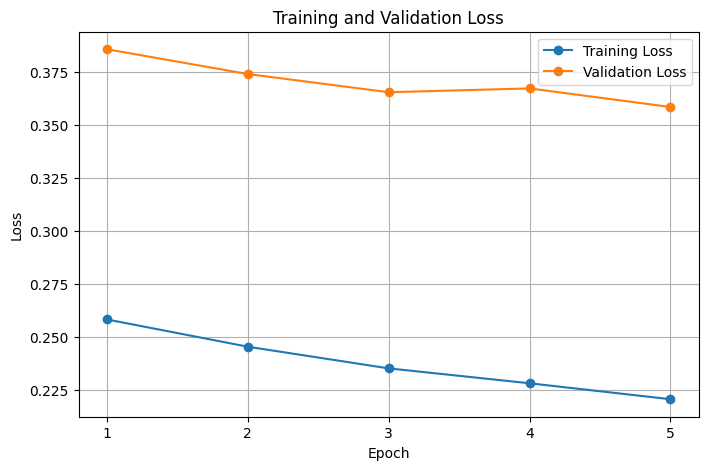

In [57]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    range(1, epochs + 1),
    val_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.xticks(range(1, epochs + 1))
plt.legend()
plt.grid(True)

plt.show()